In [ ]:
!pip install -qU langchain langgraph langgraph-checkpoint-sqlite langchain-community chromadb pysqlite3-binary pytesseract opencv-python pypdf openai

## System Setup & Imports

This notebook implements the **complete multi-agent pipeline** using:

### Core Components:
- **LangGraph** → Workflow orchestration
- **OpenAI** → LLM reasoning + extraction
- **ChromaDB** → Retrieval (RAG)
- **SQLite** → Persistent storage
- **Threading** → Parallel processing

---

### Goal:
Build an end-to-end system that:
- Reads documents
- Classifies them
- Routes them to appropriate actions

In [ ]:
import os
import json
import time
import base64
import threading
import sqlite3
from datetime import datetime

from openai import OpenAI
from langchain_core.documents import Document
from langchain_community.vectorstores import Chroma
from langchain_community.embeddings import HuggingFaceEmbeddings
from langgraph.graph import StateGraph
from langgraph.checkpoint.sqlite import SqliteSaver

from pypdf import PdfReader
import pytesseract
import cv2

## API & Environment Configuration

We load required API keys securely using Google Colab:

- **OpenAI API Key** → LLM + Vision
- **LangSmith API Key** → Tracing & debugging

---

### LangSmith Setup:
- Enables tracing of agent execution
- Helps debug workflows
- Tracks performance

---

### Data Path:
Defines where input documents are stored

In [ ]:
from google.colab import userdata
import os

os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')
os.environ["LANGCHAIN_API_KEY"] = userdata.get('LANGSMITH_API_KEY')

OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY")
LANGCHAIN_API_KEY = os.environ.get("LANGCHAIN_API_KEY")

client = OpenAI(api_key=OPENAI_API_KEY)

os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "cease-desist-agent"

DATA_PATH = "drive/MyDrive/data"

## Few-Shot + RAG Initialization

We load:

### Few-Shot Examples
- Pre-labeled document samples
- Used to guide classification

### Vector Database (Chroma)
- Stores document embeddings
- Enables similarity search

---

### Purpose:
Improve classification using:
- Past examples (few-shot)
- Context retrieval (RAG)

In [ ]:
with open("drive/MyDrive/few_shots.json") as f:
    FEW_SHOTS = json.load(f)

embedding = HuggingFaceEmbeddings()
vectordb = Chroma(persist_directory="chroma_db", embedding_function=embedding)
retriever = vectordb.as_retriever()

/tmp/ipykernel_13443/3572334891.py:4: LangChainDeprecationWarning: Default values for HuggingFaceEmbeddings.model_name were deprecated in LangChain 0.2.16 and will be removed in 0.4.0. Explicitly pass a model_name to the HuggingFaceEmbeddings constructor instead.
  embedding = HuggingFaceEmbeddings()


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## File Encoding

Converts files into Base64 format.

### Why?
- Required for sending documents to OpenAI Vision API
- Enables multimodal processing

In [ ]:
def encode_file(path):
    with open(path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")

## Text Extraction (PDF + Image)

This module extracts text using:

### PDF:
- Uses PyPDF first
- Falls back to OpenAI if extraction is weak

### Image:
- Directly uses OpenAI Vision

---

### Smart Fallback:
If traditional extraction fails → switch to LLM-based extraction

In [ ]:
def extract_with_openai(path):
    base64_file = encode_file(path)

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {
                "role": "system",
                "content": """
You are a high-accuracy OCR and entity extraction system.

1. Read the document carefully (even if rotated in any degree or noisy)
2. Extract ALL readable text
3. Identify entities:

- Full Name (person name)
- Email address
- Phone number

Return JSON:

{
  "text": "...",
  "name": "...",
  "email": "...",
  "phone": "...",
  "confidence": {
    "name": 0-1,
    "email": 0-1,
    "phone": 0-1
  }
}

Rules:
- Confidence based on clarity
- If unsure → null + low confidence
- Prefer real-world patterns (emails, phone formats)
"""
            },
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": "Extract data from this document:"},
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": f"data:image/png;base64,{base64_file}"
                        }
                    }
                ]
            }
        ],
        response_format={"type": "json_object"}
    )

    return json.loads(response.choices[0].message.content)

In [ ]:
def extract_text_from_pdf(path):
    try:
        reader = PdfReader(path)
        text = ""

        for page in reader.pages:
            if page.extract_text():
                text += page.extract_text()

        if len(text.strip()) < 300:
            print(f"Using OpenAI for PDF: {path}")
            data = extract_with_openai(path)
            return data["text"], data

        return text, {"name": None, "email": None, "phone": None}

    except:
        print(f"PyPDF failed → OpenAI fallback: {path}")
        data = extract_with_openai(path)
        return data["text"], data


def extract_text_from_image(path):
    print(f"Using OpenAI Vision for image: {path}")

    data = extract_with_openai(path)

    return data.get("text", ""), data

## State Management (LangGraph)

We define a shared state object across all agents.

### Fields:
- `file_path` → Input file
- `text` → Extracted content
- `entities` → Extracted structured data
- `label` → Classification result
- `confidence` → Model confidence
- `logs` → Audit trail

---

### Purpose:
Maintain consistency across the workflow

In [ ]:
from typing_extensions import TypedDict

class State(TypedDict):
    file_path: str
    text: str
    entities: dict
    label: str
    confidence: float
    logs: list

## Loader Agent

This is the **entry point of the pipeline**.

### Responsibilities:
- Detect file type (PDF/Image)
- Extract text
- Extract entities

---

### Output:
- Clean text
- Extracted metadata
- Log entry

In [ ]:
def loader_node(state):
    path = state.get("file_path")
    if not path:
        raise ValueError("file_path missing")

    if path.lower().endswith(".pdf"):
        text, entities = extract_text_from_pdf(path)
    else:
        text, entities = extract_text_from_image(path)

    return {
        "text": text,
        "entities": entities,
        "entity_confidence": entities.get("confidence", {}),
        "logs": state.get("logs", []) + [f"Loaded {path}"]
    }

## Classification Agent (RAG + Few-Shot)

This is the **core intelligence of the system**.

### Inputs:
- Document text
- Few-shot examples
- Retrieved context (RAG)

---

### Process:
1. Retrieve similar documents
2. Add few-shot examples
3. Send to LLM
4. Parse structured JSON output

---

### Output:
- Label (cease / uncertain / irrelevant)
- Confidence score

In [ ]:
def classifier_node(state):
    text = state["text"]
    context_docs = retriever.invoke(text[:500])
    context = "\n\n".join([d.page_content for d in context_docs])

    few_shot_text = "\n\n".join([
        f"Example:\n{ex['text']}\nLabel:{ex['label']}"
        for ex in FEW_SHOTS[:3]
    ])

    prompt = f"""
Few-shot:
{few_shot_text}

Context:
{context}

Classify the document.

Return JSON:
{{"label": "cease / uncertain / irrelevant", "confidence": 0 to 1}}

Document:
{text[:1000]}
"""

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}],
        temperature=0
    )

    try:
        parsed = json.loads(response.choices[0].message.content)
        label = parsed["label"].lower()
        confidence = float(parsed["confidence"])
    except:
        label = "uncertain"
        confidence = 0.5

    state["label"] = label
    state["confidence"] = confidence
    state["logs"].append(f"Classified {label} ({confidence})")

    return state

In [ ]:
def router(state):
    label = state["label"]
    confidence = state["confidence"]

    entity_conf = state.get("entity_confidence", {})

    if any(v is not None and v < 0.6 for v in entity_conf.values()):
        return "uncertain"

    if confidence < 0.75:
        return "uncertain"

    return label

## Database Initialization (SQLite)

We create a table to store valid **Cease requests**.

### Stored Fields:
- Filename
- Date
- Name
- Email
- Phone

---

### Purpose:
Maintain structured records for compliance

## Database Agent

Handles storage of valid **Cease documents**.

### Actions:
- Extract entity data
- Insert into SQLite database

---

### Trigger:
Only executed when label = "cease"

In [ ]:
conn = sqlite3.connect("cease.db", check_same_thread=False)
cursor = conn.cursor()

cursor.execute("""
CREATE TABLE IF NOT EXISTS cease_docs (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    filename TEXT,
    date TEXT,
    name TEXT,
    email TEXT,
    phone TEXT
)
""")
conn.commit()


def db_node(state):
    e = state.get("entities", {})

    cursor.execute(
        "INSERT INTO cease_docs VALUES (NULL, ?, ?, ?, ?, ?)",
        (
            state["file_path"],
            str(datetime.now()),
            e.get("name"),
            e.get("email"),
            e.get("phone")
        )
    )
    conn.commit()

    state["logs"].append("Stored structured entities in DB")
    return state

## Archive Agent

Handles irrelevant documents.

### Actions:
- Writes filename + timestamp to a file

---

### Trigger:
Executed when label = "irrelevant"

In [ ]:
def archive_node(state):
    with open("archive.txt", "a") as f:
        f.write(f"{state['file_path']} | {datetime.now()}\n")

    state["logs"].append("Archived")
    return state

## Human-in-the-Loop (HITL)

Handles uncertain cases.

### Process:
1. Show document preview
2. Ask human for label
3. Collect feedback

---

### Purpose:
- Improve accuracy
- Ensure compliance
- Handle edge cases

In [ ]:
memory_feedback = []

def hitl_node(state):
    print("\nHUMAN REVIEW")
    print(state["text"][:300])

    label = input("Enter label: ")
    comment = input("Comment: ")

    state["label"] = label
    memory_feedback.append(comment)

    state["logs"].append(f"HITL: {label}")
    return state


## Audit Agent

Generates a summary of all actions taken.

### Input:
- Logs from entire pipeline

---

### Output:
- Natural language audit summary

---

### Importance:
- Compliance tracking
- Debugging
- Transparency

In [ ]:
def audit_node(state):
    logs = "\n".join(state["logs"])

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": f"Summarize:\n{logs}"}]
    )

    print("\nAUDIT:")
    print(response.choices[0].message.content)

    return state


def memory_node(state):
    memory_feedback.append(state.get("label", ""))
    return state

## LangGraph Workflow Setup

We compile all agents into a **directed workflow graph**.

### Features:
- State transitions
- Conditional routing
- Persistent checkpoints

---

### Checkpointer:
Uses SQLite to:
- Save progress
- Resume workflows

In [ ]:
builder = StateGraph(State)

builder.add_node("loader", loader_node)
builder.add_node("classifier", classifier_node)
builder.add_node("db", db_node)
builder.add_node("archive", archive_node)
builder.add_node("hitl", hitl_node)
builder.add_node("audit", audit_node)
builder.add_node("memory", memory_node)

builder.set_entry_point("loader")

builder.add_edge("loader", "classifier")

builder.add_conditional_edges(
    "classifier",
    router,
    {
        "cease": "db",
        "irrelevant": "archive",
        "uncertain": "hitl"
    }
)

builder.add_edge("db", "audit")
builder.add_edge("archive", "audit")
builder.add_edge("hitl", "audit")

builder.add_edge("audit", "memory")

In [ ]:
db_path = "/content/drive/MyDrive/checkpoint.db"

checkpointer_cm = SqliteSaver.from_conn_string(db_path)
checkpointer = checkpointer_cm.__enter__()

graph = builder.compile(checkpointer=checkpointer)

## Workflow Visualization

Displays the agent pipeline as a graph.

### Helps:
- Understand flow
- Debug connections
- Present architecture

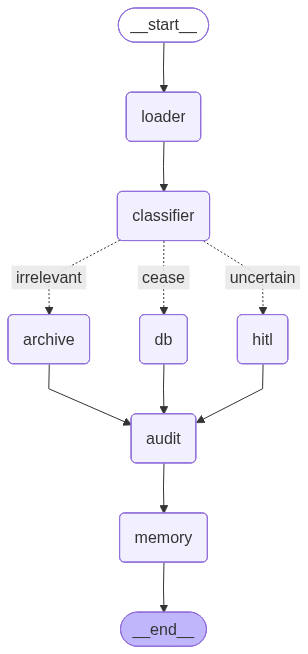

In [ ]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [ ]:
def process_file(file):
    full_path = os.path.join(DATA_PATH, file)

    result = graph.invoke(
        {
            "file_path": full_path,
            "logs": []
        },
        config={
            "configurable": {
                "thread_id": f"{file}_{threading.get_ident()}"
            }
        }
    )

    print(result)

In [ ]:
import time

def call_openai_with_retry(func, retries=5):
    for i in range(retries):
        try:
            return func()
        except Exception as e:
            if "rate_limit" in str(e):
                wait = 2 ** i
                print(f"Rate limited. Retrying in {wait}s...")
                time.sleep(wait)
            else:
                raise e

## Parallel Document Processing

We use threading to process multiple files simultaneously.

### Steps:
1. Create threads per file
2. Execute pipeline
3. Wait for completion

---

### Benefits:
- Faster processing
- Scalable system

In [ ]:
import threading

MAX_THREADS = 2

semaphore = threading.Semaphore(MAX_THREADS)

def process_file_stream(file):
    with semaphore:
        full_path = os.path.join(DATA_PATH, file)

        try:
            print(f"\n Processing: {file}")

            for event in graph.stream(
                {
                    "file_path": full_path,
                    "text": "",
                    "entities": {},
                    "label": "",
                    "confidence": 0.0,
                    "logs": []
                },
                config={
                    "configurable": {
                        "thread_id": f"{file}_{threading.get_ident()}"
                    }
                }
            ):
                pass

            print(f"Done: {file}")

        except Exception as e:
            print(f"Error in {file}: {e}")

## Final Execution

This step:

- Loads all documents
- Runs them through the pipeline
- Processes in parallel
- Stores results

---

### Output:
- Classified documents
- Stored database entries
- Archived files
- Audit logs

---

System execution complete!

In [ ]:
threads = []

files = [
    f for f in os.listdir(DATA_PATH)
    if f.lower().endswith((".pdf", ".jpg", ".jpeg", ".png"))
]

for file in files:
    t = threading.Thread(target=process_file_stream, args=(file,))
    t.start()
    threads.append(t)

for t in threads:
    t.join()

print("\nALL FILES PROCESSED")


 Processing: 20251009_111301.jpg
Using OpenAI Vision for image: drive/MyDrive/data/20251009_111301.jpg

AUDIT:
The image "20251009_111301.jpg" has been analyzed and classified as irrelevant with a confidence score of 0.9, and it has been archived.
Done: 20251009_111301.jpg

 Processing: 20251009_111416.jpg
Using OpenAI Vision for image: drive/MyDrive/data/20251009_111416.jpg

AUDIT:
The image labeled "20251009_111416.jpg" has been analyzed, classified with a certainty of 1.0 as "cease," and the structured data entities have been stored in a database.
Done: 20251009_111416.jpg

 Processing: 20251009_111232.jpg
Using OpenAI Vision for image: drive/MyDrive/data/20251009_111232.jpg

AUDIT:
A file named "20251009_111232.jpg" was processed, classified with a high confidence score of 0.95 as "cease," and its structured data was stored in a database.
Done: 20251009_111232.jpg

 Processing: 20251009_105300.jpg
Using OpenAI Vision for image: drive/MyDrive/data/20251009_105300.jpg

AUDIT:
The im